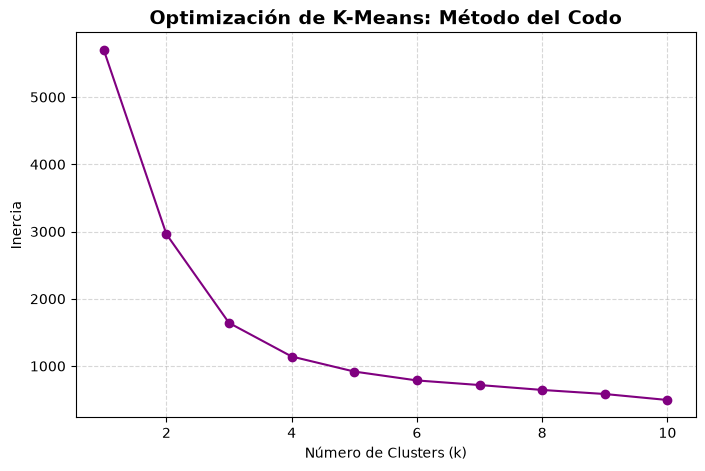

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Carga de datos
df_samsung = pd.read_csv('samsung.xls')

# 2. Limpieza: Seleccionamos ÚNICAMENTE las columnas numéricas (ignoramos fechas o textos)
X_sam = df_samsung.select_dtypes(include=['number'])

# Opcional: Si el dataset tiene una columna ID o Subject que sea número pero no aporte valor,
# puedes descomentar la siguiente línea y poner el nombre de la columna para eliminarla:
# X_sam = X_sam.drop(columns=['nombre_columna_id'], errors='ignore')

# 3. Escalamiento de datos (VITAL para K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sam)

# 4. Búsqueda de Hiperparámetro K (Método del Codo)
inercia = []
rango_k = range(1, 11)

for k in rango_k:
    modelo_kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    modelo_kmeans.fit(X_scaled)
    inercia.append(modelo_kmeans.inertia_)

# Graficar el Método del Codo
plt.figure(figsize=(8, 5))
plt.plot(rango_k, inercia, marker='o', linestyle='-', color='purple')
plt.title('Optimización de K-Means: Método del Codo', fontsize=14, fontweight='bold')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

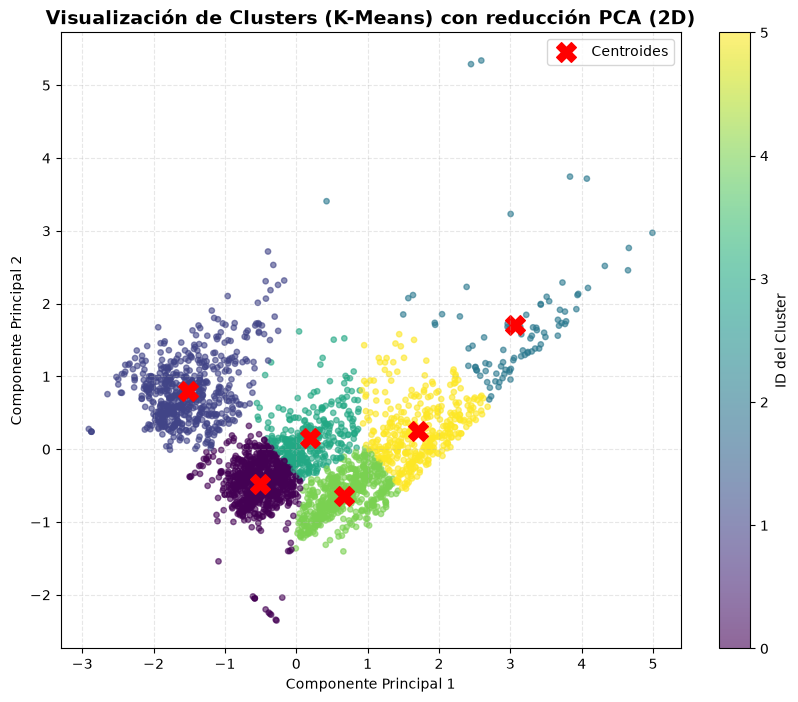

In [4]:
# 4. Entrenar Modelo Final con k=6
k_optimo = 6
kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init='auto')
clusters = kmeans_final.fit_predict(X_scaled)

# 5. Reducción PCA para poder graficar (pasar de 500+ columnas a solo 2)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 6. Graficar Clusters Finales
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', alpha=0.6, s=15)

# Graficar Centroides
centroides_pca = pca.transform(kmeans_final.cluster_centers_)
plt.scatter(centroides_pca[:, 0], centroides_pca[:, 1], c='red', marker='X', s=200, label='Centroides')

plt.title('Visualización de Clusters (K-Means) con reducción PCA (2D)', fontsize=14, fontweight='bold')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.colorbar(scatter, label='ID del Cluster')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()